<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/practical02(MV_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib imutils

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import imutils

Saving C3PUSRLMO0DW17J69E5Z.jpg to C3PUSRLMO0DW17J69E5Z.jpg
Saving C4HWMAS375IZJQBRLTKY.jpg to C4HWMAS375IZJQBRLTKY.jpg
Saving C6FDZ7I4BAQVEL3O8KMY.jpg to C6FDZ7I4BAQVEL3O8KMY.jpg
Saving C7AJIN4HGVMZYDPTQ5ER.jpg to C7AJIN4HGVMZYDPTQ5ER.jpg
Saving C18V3FYS57IQ9PMUT6JA.jpg to C18V3FYS57IQ9PMUT6JA.jpg
Saving C19GKOAL0N567IMEBWZ3.jpg to C19GKOAL0N567IMEBWZ3.jpg
Saving C52Z4DTVJE3ONR71PMLB.jpg to C52Z4DTVJE3ONR71PMLB.jpg
Saving CB5OIPY8D72FNX0SJHQK.jpg to CB5OIPY8D72FNX0SJHQK.jpg
Saving CE3D7Y81RN96LXUOJZHM.jpg to CE3D7Y81RN96LXUOJZHM.jpg
Saving CFD6AU8BVELXYWJZ572K.jpg to CFD6AU8BVELXYWJZ572K.jpg
Saving CGJPXZRA0IQ28STYF349.jpg to CGJPXZRA0IQ28STYF349.jpg
Saving CK0I236HNPQF5LAE8BT7.jpg to CK0I236HNPQF5LAE8BT7.jpg
Saving CLFYO06NB4MT3QKH7A98.jpg to CLFYO06NB4MT3QKH7A98.jpg
Saving CNH1JD5USMOY4BAPTXV0.jpg to CNH1JD5USMOY4BAPTXV0.jpg


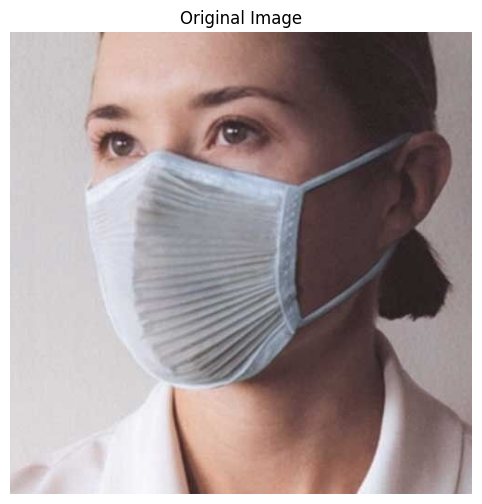

In [3]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

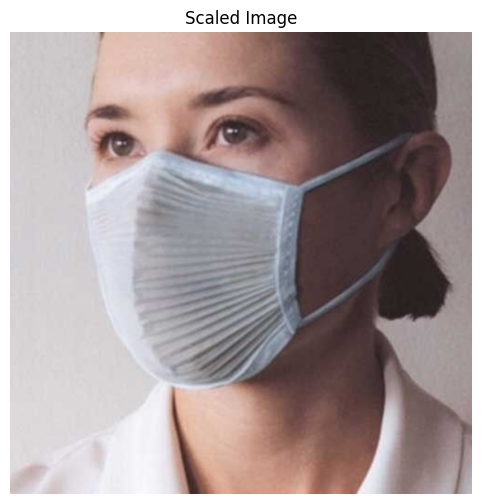

In [4]:
scale_factor = 1.5

scaled = cv2.resize(image, None,
                    fx=scale_factor,
                    fy=scale_factor,
                    interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(8,6))
plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()

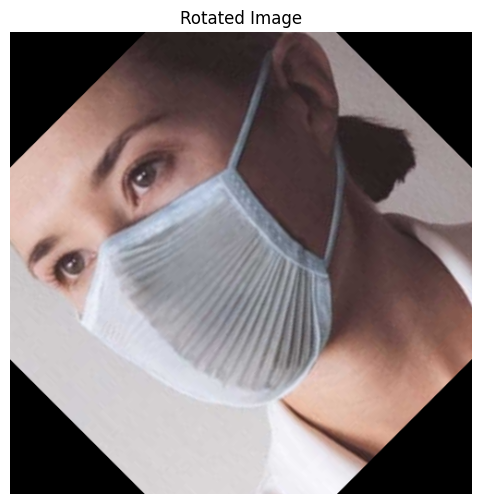

In [5]:
angle = 45

(h, w) = image.shape[:2]
center = (w//2, h//2)

rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1)

rotated = cv2.warpAffine(image,
                         rotation_matrix,
                         (w, h))

plt.figure(figsize=(8,6))
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()

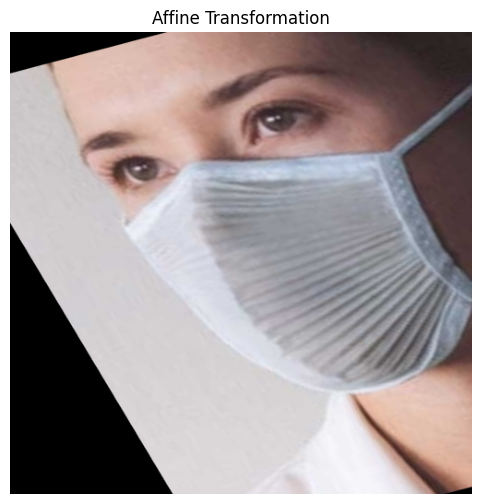

In [6]:
rows, cols = image.shape[:2]

pts1 = np.float32([[50,50],
                   [200,50],
                   [50,200]])

pts2 = np.float32([[10,100],
                   [200,50],
                   [100,250]])

matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(image,
                        matrix,
                        (cols, rows))

plt.figure(figsize=(8,6))
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

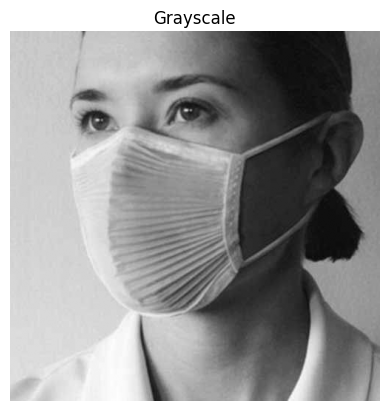

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

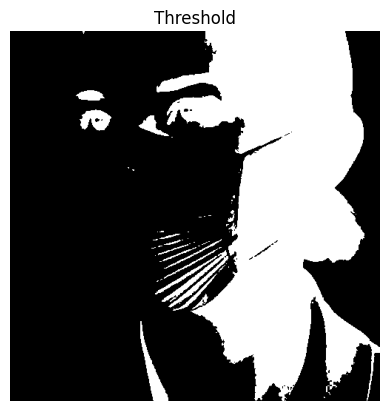

In [8]:
_, thresh = cv2.threshold(gray,
                          120,
                          255,
                          cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")
plt.show()

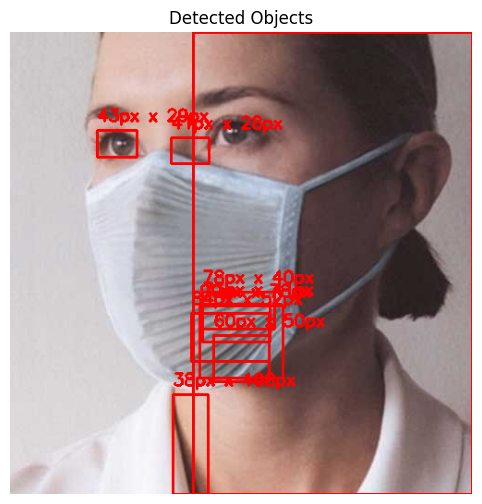

In [9]:
contours, _ = cv2.findContours(thresh,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    if w>20 and h>20:

        cv2.rectangle(output,
                      (x,y),
                      (x+w,y+h),
                      (255,0,0),
                      2)

        cv2.putText(output,
                    f"{w}px x {h}px",
                    (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2)

plt.figure(figsize=(8,6))
plt.imshow(output)
plt.title("Detected Objects")
plt.axis("off")
plt.show()

In [11]:
reference_width_cm = 2.0

reference_pixels = 100

pixels_per_cm = reference_pixels / reference_width_cm

print("Pixels per cm =", pixels_per_cm)

Pixels per cm = 50.0


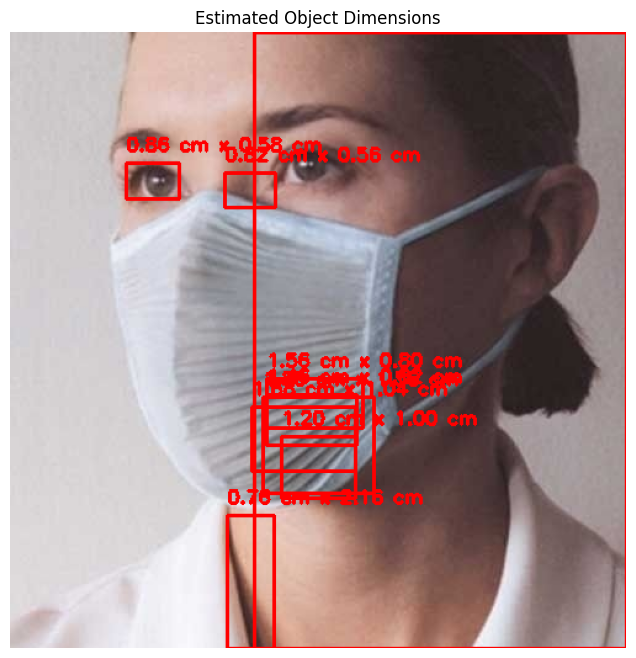

In [12]:
output = image.copy()

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    if w>20 and h>20:

        width_cm = w / pixels_per_cm
        height_cm = h / pixels_per_cm

        cv2.rectangle(output,
                      (x,y),
                      (x+w,y+h),
                      (255,0,0),
                      2)

        text = f"{width_cm:.2f} cm x {height_cm:.2f} cm"

        cv2.putText(output,
                    text,
                    (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255,0,0),
                    2)

plt.figure(figsize=(10,8))
plt.imshow(output)
plt.title("Estimated Object Dimensions")
plt.axis("off")
plt.show()

In [13]:
print("Object Measurements:")

for i, cnt in enumerate(contours):

    x,y,w,h = cv2.boundingRect(cnt)

    if w>20 and h>20:

        width_cm = w / pixels_per_cm
        height_cm = h / pixels_per_cm

        print(f"Object {i+1}")
        print(f"Width : {width_cm:.2f} cm")
        print(f"Height: {height_cm:.2f} cm")
        print("---------------------")

Object Measurements:
Object 6
Width : 0.76 cm
Height: 2.16 cm
---------------------
Object 10
Width : 1.20 cm
Height: 1.00 cm
---------------------
Object 15
Width : 1.68 cm
Height: 1.04 cm
---------------------
Object 17
Width : 1.80 cm
Height: 1.56 cm
---------------------
Object 18
Width : 1.46 cm
Height: 0.82 cm
---------------------
Object 31
Width : 1.56 cm
Height: 0.80 cm
---------------------
Object 53
Width : 0.82 cm
Height: 0.56 cm
---------------------
Object 54
Width : 0.86 cm
Height: 0.58 cm
---------------------
Object 57
Width : 6.04 cm
Height: 10.00 cm
---------------------
